<a href="https://colab.research.google.com/github/Aayan783/BrainTumourDetection/blob/main/ChronicBrainMRItmourDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/CHRONIC

chronic  chronic_mask


In [ ]:
import os

# Define the dataset path
dataset_path = "/content/drive/MyDrive/CHRONIC"

# Function to get file paths
def list_file_paths(directory):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

# Get file paths for each category
chronic_paths = list_file_paths(os.path.join(dataset_path, "chronic"))
chronic_mask_paths = list_file_paths(os.path.join(dataset_path, "chronic_mask"))

# Display a sample
print("Sample Acute MRI File:", chronic_paths[0] if chronic_paths else "No files found")
print("Sample Acute Mask File:", chronic_mask_paths[0] if chronic_mask_paths else "No files found")


Sample Acute MRI File: /content/drive/MyDrive/CHRONIC/chronic/10014.png
Sample Acute Mask File: /content/drive/MyDrive/CHRONIC/chronic_mask/1319.png


In [ ]:
# Create dictionaries for fast lookup
chronic_files = {os.path.splitext(os.path.basename(p))[0]: p for p in chronic_paths}
chronic_mask_files = {os.path.splitext(os.path.basename(p))[0]: p for p in chronic_mask_paths}

# Match images and masks
matched_pairs = []
for key in chronic_files:
    if key in chronic_mask_files:
        matched_pairs.append((chronic_files[key], chronic_mask_files[key]))

print(f"Total matched image-mask pairs: {len(matched_pairs)}")

# Preview a sample pair
sample_img_path, sample_mask_path = matched_pairs[0]
print("Sample matched MRI:", sample_img_path)
print("Sample matched Mask:", sample_mask_path)


Total matched image-mask pairs: 110
Sample matched MRI: /content/drive/MyDrive/CHRONIC/chronic/13176.png
Sample matched Mask: /content/drive/MyDrive/CHRONIC/chronic_mask/13176.png


In [ ]:
import cv2
import numpy as np

IMG_SIZE = (224, 224)

# Preprocessing function
def preprocess_data(pairs):
    images = []
    masks = []

    for img_path, mask_path in pairs:
        # Load and resize MRI image (grayscale)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE)
        img = img / 255.0  # Normalize to [0,1]
        img = np.expand_dims(img, axis=-1)  # Add channel dim

        # Load and resize mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, IMG_SIZE)
        mask = (mask > 127).astype(np.uint8)  # Binarize
        mask = np.expand_dims(mask, axis=-1)  # Add channel dim

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

# Apply preprocessing
images, masks = preprocess_data(matched_pairs)

print("Image shape:", images.shape)
print("Mask shape:", masks.shape)

Image shape: (110, 224, 224, 1)
Mask shape: (110, 224, 224, 1)


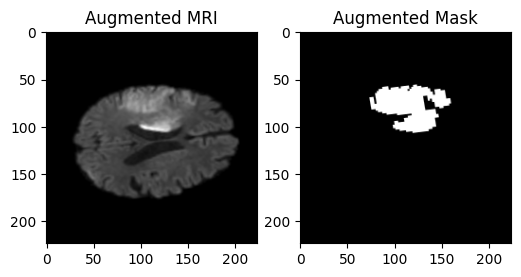

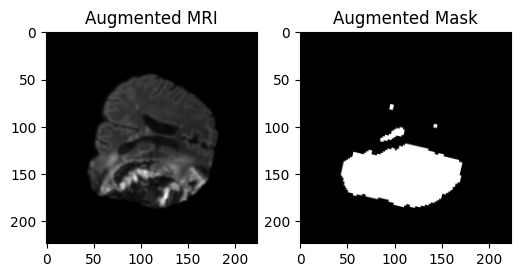

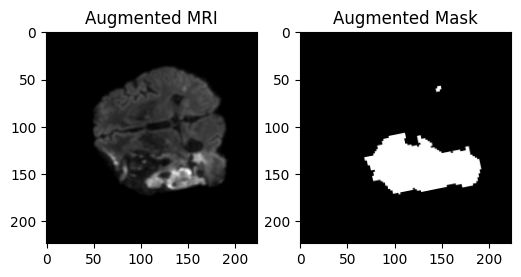

In [ ]:
# Data Agumentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the same seed for image and mask generators
seed = 42

# Create data generators for both images and masks
image_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

mask_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fit the generators (not strictly necessary here but good for completeness)
image_datagen.fit(images, augment=True, seed=seed)
mask_datagen.fit(masks, augment=True, seed=seed)

# Create generator that yields augmented images and masks together
train_generator = zip(
    image_datagen.flow(images, batch_size=8, seed=seed),
    mask_datagen.flow(masks, batch_size=8, seed=seed)
)

# Preview a few augmented pairs
import matplotlib.pyplot as plt

aug_img_batch, aug_mask_batch = next(train_generator)

for i in range(3):
    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.title("Augmented MRI")
    plt.imshow(aug_img_batch[i].squeeze(), cmap='gray')

    plt.subplot(1,2,2)
    plt.title("Augmented Mask")
    plt.imshow(aug_mask_batch[i].squeeze(), cmap='gray')

    plt.show()

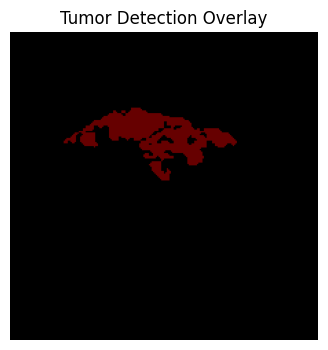

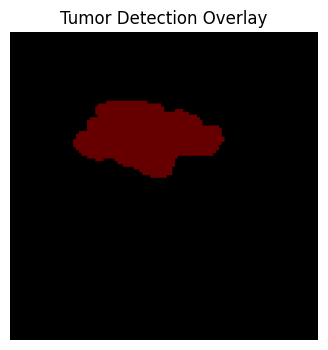

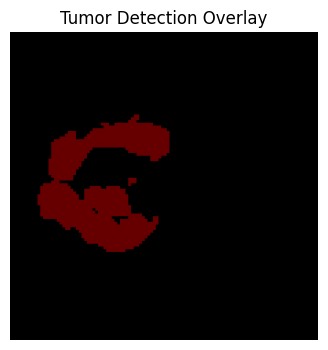

In [ ]:
# Overlay Mask on MRI Scan
def overlay_mask(image, mask, color=(255, 0, 0), alpha=0.4):
    """
    Overlay a binary mask on an image.
    Args:
        image: Grayscale image with shape (224, 224, 1)
        mask: Binary mask with shape (224, 224, 1)
        color: RGB tuple for overlay
        alpha: Transparency level
    Returns:
        Overlayed RGB image
    """
    image_rgb = np.repeat(image, 3, axis=-1)  # Convert to RGB
    mask = mask.squeeze()  # Remove channel dimension

    # Create a color mask
    color_mask = np.zeros_like(image_rgb)
    for i in range(3):
        color_mask[:, :, i] = mask * color[i]

    # Blend the mask with the original image
    overlayed = cv2.addWeighted(image_rgb.astype('float32'), 1.0,
                                color_mask.astype('float32'), alpha, 0)
    return overlayed.astype(np.uint8)

# Display a few overlayed results
for i in range(3):
    overlaid_img = overlay_mask(images[i], masks[i])
    plt.figure(figsize=(4,4))
    plt.title("Tumor Detection Overlay")
    plt.imshow(overlaid_img)
    plt.axis('off')
    plt.show()

In [ ]:
# Creating binary labels
# Create labels: 1 if tumor present in mask, else 0
labels = np.array([(mask > 0).any() for mask in masks], dtype=np.uint8)

print("Number of tumor images:", np.sum(labels))
print("Number of non-tumor images:", len(labels) - np.sum(labels))

Number of tumor images: 110
Number of non-tumor images: 0


In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_val, y_train, y_val = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

In [ ]:
# Using PRE-TRAINED MODEL(Mobile Net V2)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam

# Expand grayscale images to 3 channels
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)

# Define model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train_rgb, y_train, validation_data=(X_val_rgb, y_val), epochs=10, batch_size=8)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 555ms/step - accuracy: 1.0000 - loss: 0.1139 - val_accuracy: 1.0000 - val_loss: 0.0242
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 438ms/step - accuracy: 1.0000 - loss: 0.0143 - val_accuracy: 1.0000 - val_loss: 0.0067
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 365ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 300ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 462ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 366ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 399ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 593ms/step - 

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam

# Expand grayscale images to 3 channels
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)

# Define model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train_rgb, y_train, validation_data=(X_val_rgb, y_val), epochs=10, batch_size=8)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 499ms/step - accuracy: 0.5148 - loss: 0.6631 - val_accuracy: 1.0000 - val_loss: 0.1479
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 520ms/step - accuracy: 1.0000 - loss: 0.0900 - val_accuracy: 1.0000 - val_loss: 0.0386
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 307ms/step - accuracy: 1.0000 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0185
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 373ms/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 0.0123
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 443ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0095
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 371ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 0.0079
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 410ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0067
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 368ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1

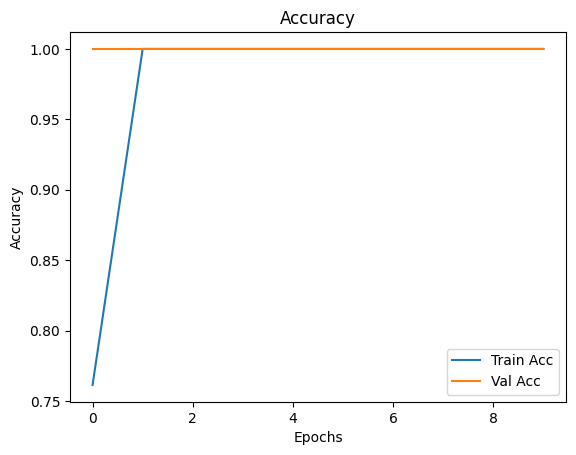

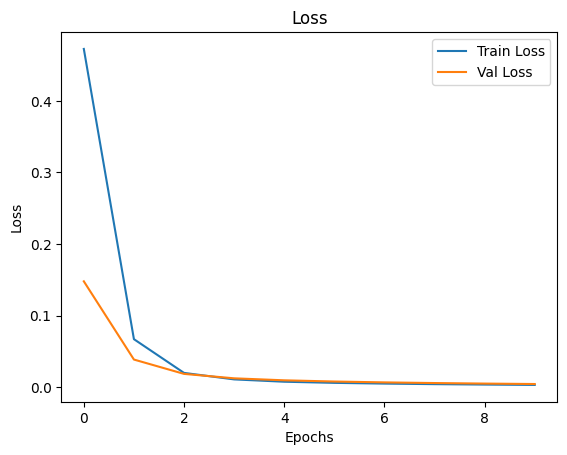

In [ ]:
# Plotting Training History
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Explicitly define labels to avoid mismatch errors
labels_all = [0, 1]

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred, labels=labels_all)
print("Confusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_val, y_pred, labels=labels_all, target_names=['No Tumor', 'Tumor'], zero_division=0)
print("Classification Report:\n", report)


Confusion Matrix:
 [[ 0  0]
 [ 0 22]]
Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.00      0.00      0.00         0
       Tumor       1.00      1.00      1.00        22

    accuracy                           1.00        22
   macro avg       0.50      0.50      0.50        22
weighted avg       1.00      1.00      1.00        22



In [ ]:
unique_all, counts_all = np.unique(labels, return_counts=True)
print("Full Dataset Distribution:", dict(zip(unique_all, counts_all)))

Full Dataset Distribution: {np.uint8(1): np.int64(110)}


In [ ]:
from sklearn.model_selection import train_test_split

# Ensure both classes appear in train and val
X_train, X_val, y_train, y_val = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42
)

# Repeat the grayscale-to-RGB conversion
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)

In [ ]:
import numpy as np

# Check how many images have tumor (label=1) and no tumor (label=0)
labels = np.array([(mask > 0).any() for mask in masks], dtype=np.uint8)
unique_all, counts_all = np.unique(labels, return_counts=True)
print("Full Dataset Class Distribution:", dict(zip(unique_all, counts_all)))

Full Dataset Class Distribution: {np.uint8(1): np.int64(110)}


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels  # <-- ensures balanced classes
)

In [ ]:
# Convert grayscale images to RGB by repeating the channel
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)

print("Train shape:", X_train_rgb.shape)
print("Validation shape:", X_val_rgb.shape)

Train shape: (88, 224, 224, 3)
Validation shape: (22, 224, 224, 3)


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Define base model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Compile
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=10,
    batch_size=8
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 502ms/step - accuracy: 0.9676 - loss: 0.3212 - val_accuracy: 1.0000 - val_loss: 0.0685
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 412ms/step - accuracy: 1.0000 - loss: 0.0386 - val_accuracy: 1.0000 - val_loss: 0.0187
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 307ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 1.0000 - val_loss: 0.0095
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 0.0064
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 469ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 303ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 302ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 367ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict
y_pred_probs = model.predict(X_val_rgb)
y_pred = (y_pred_probs > 0.5).astype('int32')

# Confusion matrix & report
cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

report = classification_report(y_val, y_pred, labels=[0, 1], target_names=['No Tumor', 'Tumor'], zero_division=0)
print("Classification Report:\n", report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Confusion Matrix:
 [[ 0  0]
 [ 0 22]]
Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.00      0.00      0.00         0
       Tumor       1.00      1.00      1.00        22

    accuracy                           1.00        22
   macro avg       0.50      0.50      0.50        22
weighted avg       1.00      1.00      1.00        22



In [ ]:
# Normalize images and masks to [0, 1]
images = images.astype('float32') / 255.0
masks = masks.astype('float32') / 255.0

# If needed, convert masks to binary (0 or 1)
masks = (masks > 0.5).astype('float32')

# Split into training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (88, 224, 224, 1)
Val shape: (22, 224, 224, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def unet_model(input_size=(224, 224, 1)):
    inputs = tf.keras.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    b = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(512, 3, activation='relu', padding='same')(b)

    # Decoder
    u3 = layers.UpSampling2D((2, 2))(b)
    u3 = layers.concatenate([u3, c3])
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(c5)

    u1 = layers.UpSampling2D((2, 2))(c5)
    u1 = layers.concatenate([u1, c1])
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    model = Model(inputs, outputs)
    return model

# Create the model
model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 224, 224, 64)   │            640 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 224, 224, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 112, 112, 64)   │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 112, 112, 128)  │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 112, 112, 128)  │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 56, 56, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 56, 56, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 56, 56, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 28, 28, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 28, 28, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 28, 28, 512)    │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d             │ (None, 56, 56, 512)    │              0 │ conv2d_7[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 56, 56, 768)    │              0 │ up_sampling2d[0][0],   │
│                           │                        │                │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 56, 56, 256)    │      1,769,728 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 56, 56, 256)    │        590,080 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_1      

 Total params: 7,781,761 (29.69 MB)

 Trainable params: 7,781,761 (29.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 422s 38s/step - accuracy: 0.9059 - loss: 0.4186 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 442s 38s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 407s 37s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 447s 38s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 445s 38s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 435s 38s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 444s 38s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 440s 37s/step 

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


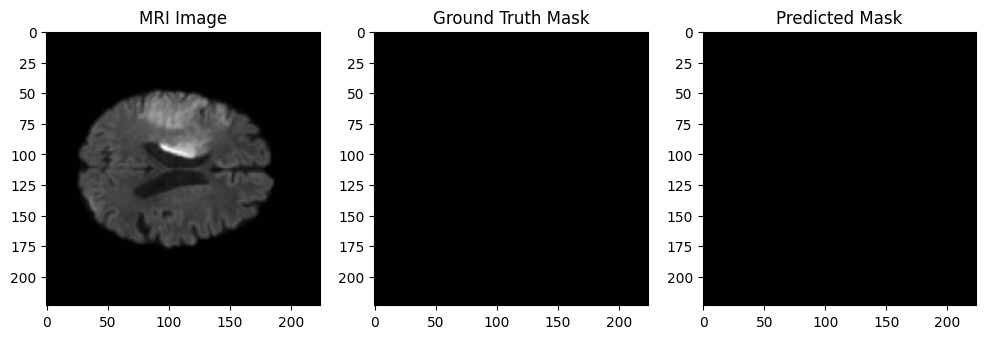

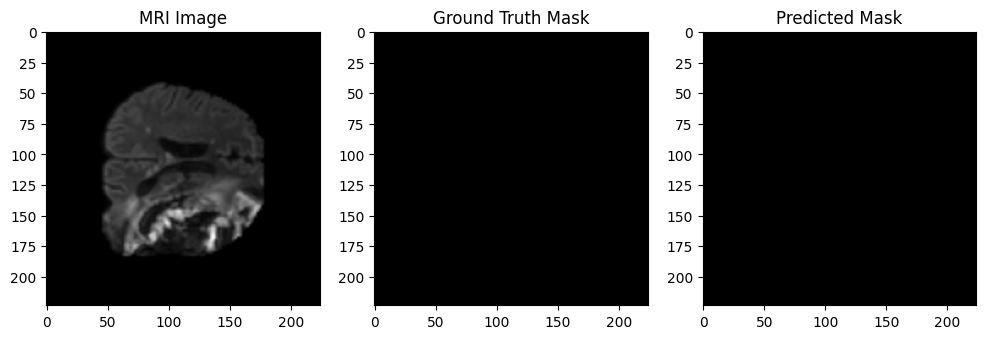

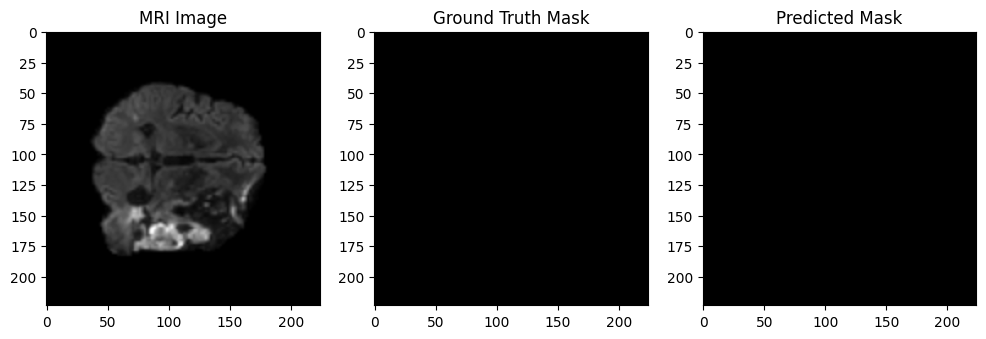

In [ ]:
import matplotlib.pyplot as plt

def show_predictions(model, images, masks, num=3):
    preds = model.predict(images[:num])
    for i in range(num):
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.title("MRI Image")
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.subplot(1, 3, 2)
        plt.title("Ground Truth Mask")
        plt.imshow(masks[i].squeeze(), cmap='gray')
        plt.subplot(1, 3, 3)
        plt.title("Predicted Mask")
        plt.imshow(preds[i].squeeze(), cmap='gray')
        plt.show()

show_predictions(model, X_val, y_val)

In [ ]:
import tensorflow.keras.backend as K

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [ ]:
import numpy as np

# Predict masks
preds = model.predict(X_val)
preds_binary = (preds > 0.5).astype(np.float32)

# Compute metrics for each sample
dice_scores = [dice_coefficient(y_true, y_pred).numpy() for y_true, y_pred in zip(y_val, preds_binary)]
iou_scores = [iou_score(y_true, y_pred).numpy() for y_true, y_pred in zip(y_val, preds_binary)]

print(f"Average Dice Score: {np.mean(dice_scores):.4f}")
print(f"Average IoU Score: {np.mean(iou_scores):.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step
Average Dice Score: 1.0000
Average IoU Score: 1.0000


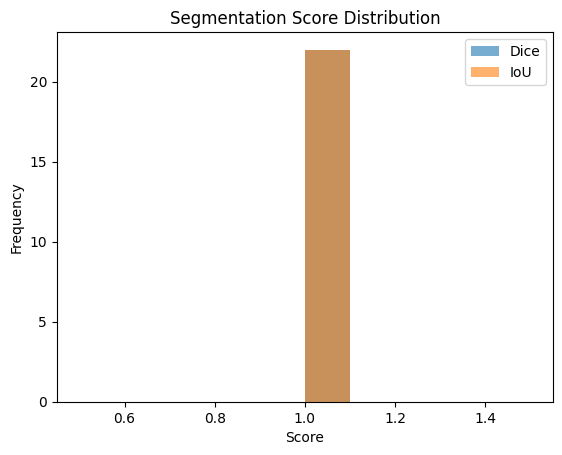

In [ ]:
import matplotlib.pyplot as plt

plt.hist(dice_scores, bins=10, alpha=0.6, label="Dice")
plt.hist(iou_scores, bins=10, alpha=0.6, label="IoU")
plt.title("Segmentation Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# Save the model in HDF5 format
model.save("/content/unet_brain_tumor_segmentation.h5")

# Optional: Save to Google Drive
!cp /content/unet_brain_tumor_segmentation.h5 /content/drive/MyDrive/

In [1]:
!apt-get install git


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.12).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


Cloning into 'BrainTumourDetection'...


/bin/bash: line 1: gh: command not found


/content/BrainTumourDetection
error: 'BrainTumourDetection/' does not have a commit checked out
fatal: adding files failed
On branch main
Your branch is based on 'origin/main', but the upstream is gone.
  (use "git branch --unset-upstream" to fixup)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	BrainTumourDetection/

nothing added to commit but untracked files present (use "git add" to track)
fatal: could not read Username for 'https://github.com': No such device or address
